In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap.umap_ as umap

from sklearn.preprocessing import StandardScaler

/Users/aryuh/Documents/ev_digital_city/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


##### Fetch data

In [44]:
households_df = pd.read_csv("data/household.csv")
vehicles_df = pd.read_csv("data/vehicle.csv")
trips_df = pd.read_csv("data/trip.csv")
person_df = pd.read_csv("data/person.csv")

In [45]:
COUNTY_LOOKUP = {
    11001: "District of Columbia",
    24003: "Anne Arundel",
    24009: "Calvert",
    24013: "Carroll",
    24017: "Charles",
    24021: "Frederick",
    24027: "Howard",
    24031: "Montgomery",
    24033: "Prince George's",
    24037: "St. Mary's",
    51013: "Arlington",
    51043: "Clarke",
    51059: "Fairfax county",
    51061: "Fauquier",
    51099: "King George",
    51107: "Loudoun",
    51153: "Prince William",
    51177: "Spotsylvania",
    51179: "Stafford",
    51510: "Alexandria (city)",
    51600: "Fairfax (city)",
    51610: "Falls Church (city)",
    51630: "Fredericksburg (city)",
    51683: "Manassas (city)",
    51685: "Manassas Park (city)",
    54037: "Jefferson",
}

##### EVs in county helper

In [46]:
def ev_data_in_county(county_code: int | None):
    if county_code:
        # Select households only in county code
        county_households_df = households_df[households_df["HOME_STATE_COUNTY_FIPS"] == county_code]
    else:
        # Select all households
        county_households_df = households_df.copy()
    
    where = f"county ({COUNTY_LOOKUP[county_code]})" if county_code else "dataset"

    # Select eletric vehicles only in county households
    county_evs_df = vehicles_df[(vehicles_df["FUELTYPE"] == 5) & (vehicles_df["HOUSEHOLD_ID"].isin(county_households_df["HOUSEHOLD_ID"]))]

    print(f"Number of EVs in {where}: {len(county_evs_df)}")

    # Select trips that are part of a household with an eletric vehicle
    ev_trips_df = trips_df[trips_df["HOUSEHOLD_ID"].isin(county_evs_df["HOUSEHOLD_ID"])]
    
    print(f"Number of EV trips in {where}: {len(ev_trips_df)}")

    # Merge dataframes
    df = pd.merge(person_df, ev_trips_df, on = ["HOUSEHOLD_ID", "PERSON_ID"])
    df = pd.merge(county_households_df, df, on = "HOUSEHOLD_ID")
    
    # Select columns
    df = df[["D_ACTIVITY", "TRAVELERS_TOTAL", "DISTANCE", "REPORTED_TRAVEL_TIME", "AGE", "GENDER", "EMPLOYMENT_STATUS", "J1_COMMUTE_FREQ", "J1_TELECOMMUTE_DAYS", "J1_BENEFITS_CARPOOL", "J1_BENEFITS_EV_CHARGING", "J1_BENEFITS_FREE_PARKING", "STUDENT_STATUS", "SCHOOL_FREQ", "HOME_TYPE", "HOME_OWNERSHIP", "HHSIZE", "NUMSTUDENTS", "NUMDRIVERS", "NUMWORKERS", "NUMVEHICLE", "HH_INCOME_DETAILED", "HHTRIPS"]]

    return df


##### EVs in entire dataset

In [47]:
ev_data_in_county(None)

Number of EVs in dataset: 107
Number of EV trips in dataset: 832


,D_ACTIVITY,TRAVELERS_TOTAL,DISTANCE,REPORTED_TRAVEL_TIME,AGE,GENDER,EMPLOYMENT_STATUS,J1_COMMUTE_FREQ,J1_TELECOMMUTE_DAYS,J1_BENEFITS_CARPOOL,...,SCHOOL_FREQ,HOME_TYPE,HOME_OWNERSHIP,HHSIZE,NUMSTUDENTS,NUMDRIVERS,NUMWORKERS,NUMVEHICLE,HH_INCOME_DETAILED,HHTRIPS
0,9,1,1.217000,15,68,1,1,-9,-9,-9,...,-9,3,2,1,0,0,0,1,3,4
1,4,1,1.220000,15,68,1,1,-9,-9,-9,...,-9,3,2,1,0,0,0,1,3,4
2,5,1,0.271000,109,68,1,1,-9,-9,-9,...,-9,3,2,1,0,0,0,1,3,4
3,1,1,0.399000,18,68,1,1,-9,-9,-9,...,-9,3,2,1,0,0,0,1,3,4
4,2,1,12.335000,20,44,2,0,-9,0,0,...,-9,1,1,4,2,2,2,2,7,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
827,1,1,16.551218,30,39,1,0,-9,-9,-9,...,-9,2,1,2,0,2,2,3,8,6
828,2,1,45.496909,90,40,2,0,1,0,0,...,-9,2,1,2,0,2,2,3,8,6
829,1,1,45.496909,80,40,2,0,1,0,0,...,-9,2,1,2,0,2,2,3,8,6
830,6,1,1.108796,5,40,2,0,1,0,0,...,-9,2,1,2,0,2,2,3,8,6


##### EVs per county

In [48]:
for code in sorted(COUNTY_LOOKUP.keys()):
    ev_data_in_county(code)
    print()

Number of EVs in county (District of Columbia): 5
Number of EV trips in county (District of Columbia): 57

Number of EVs in county (Anne Arundel): 4
Number of EV trips in county (Anne Arundel): 20

Number of EVs in county (Calvert): 1
Number of EV trips in county (Calvert): 5

Number of EVs in county (Carroll): 1
Number of EV trips in county (Carroll): 0

Number of EVs in county (Charles): 0
Number of EV trips in county (Charles): 0

Number of EVs in county (Frederick): 5
Number of EV trips in county (Frederick): 56

Number of EVs in county (Howard): 4
Number of EV trips in county (Howard): 21

Number of EVs in county (Montgomery): 21
Number of EV trips in county (Montgomery): 189

Number of EVs in county (Prince George's): 9
Number of EV trips in county (Prince George's): 62

Number of EVs in county (St. Mary's): 0
Number of EV trips in county (St. Mary's): 0

Number of EVs in county (Arlington): 13
Number of EV trips in county (Arlington): 113

Number of EVs in county (Clarke): 1
Num

Number of EVs in dataset: 107
Number of EV trips in dataset: 832


/Users/aryuh/Documents/ev_digital_city/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


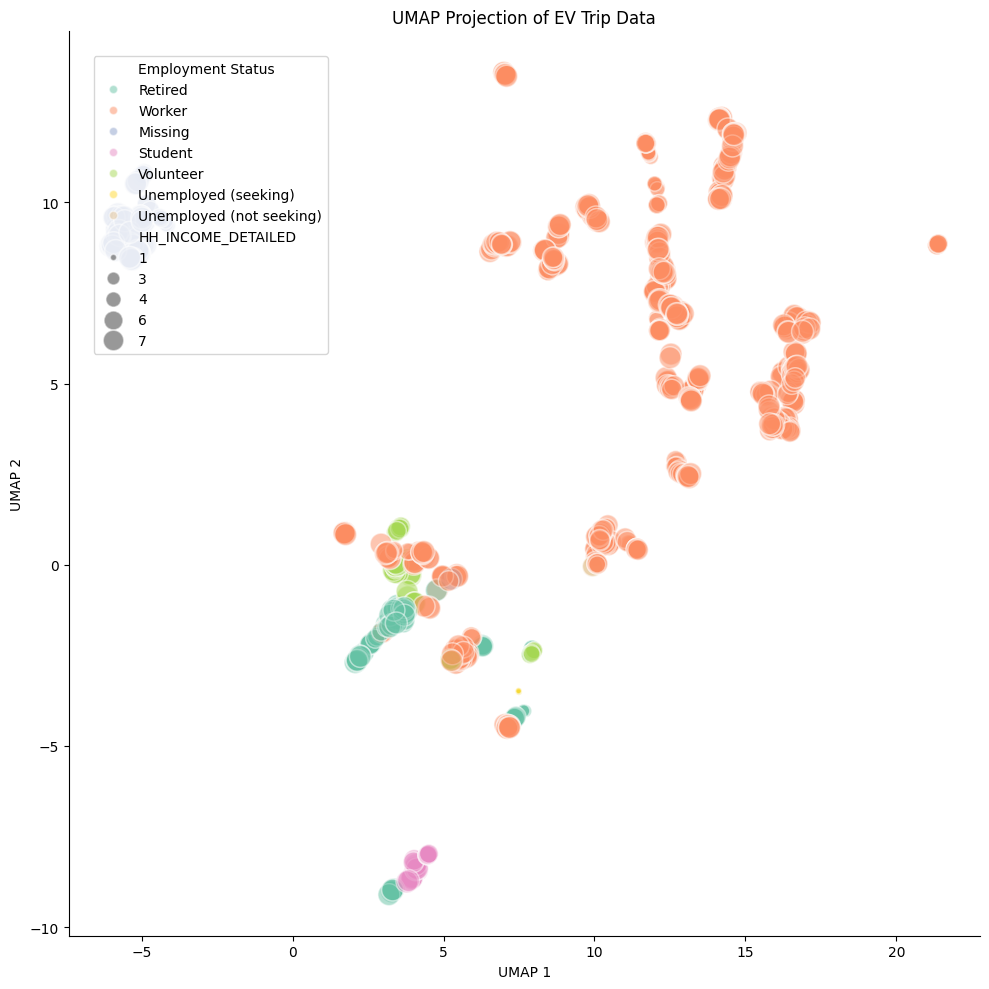

In [51]:
df = ev_data_in_county(None)

scaled_df = StandardScaler().fit_transform(df)
embedding = umap.UMAP(n_components = 2, random_state = 42).fit_transform(scaled_df)

umap_df = pd.DataFrame(embedding, columns = ["UMAP1", "UMAP2"])
umap_df["HH_INCOME_DETAILED"] = df["HH_INCOME_DETAILED"].values
employment_labels = {
    -9: "Missing",
    0: "Worker",
    1: "Retired",
    2: "Volunteer",
    3: "Homemaker",
    4: "Unemployed (seeking)",
    5: "Unemployed (not seeking)",
    6: "Student",
    7: "Disabled non-worker",
}
umap_df["Employment Status"] = df["EMPLOYMENT_STATUS"].map(employment_labels)

plt.figure(figsize = (10, 10))
ax = sns.scatterplot(data = umap_df, x = "UMAP1", y = "UMAP2", size = "HH_INCOME_DETAILED", hue = "Employment Status", sizes = (20, 250), palette = "Set2", alpha = 0.5)
plt.title("UMAP Projection of EV Trip Data")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
ax.legend(loc = "upper left", bbox_to_anchor = (0.02, 0.98), frameon = True)
sns.despine()
plt.tight_layout()
plt.show()

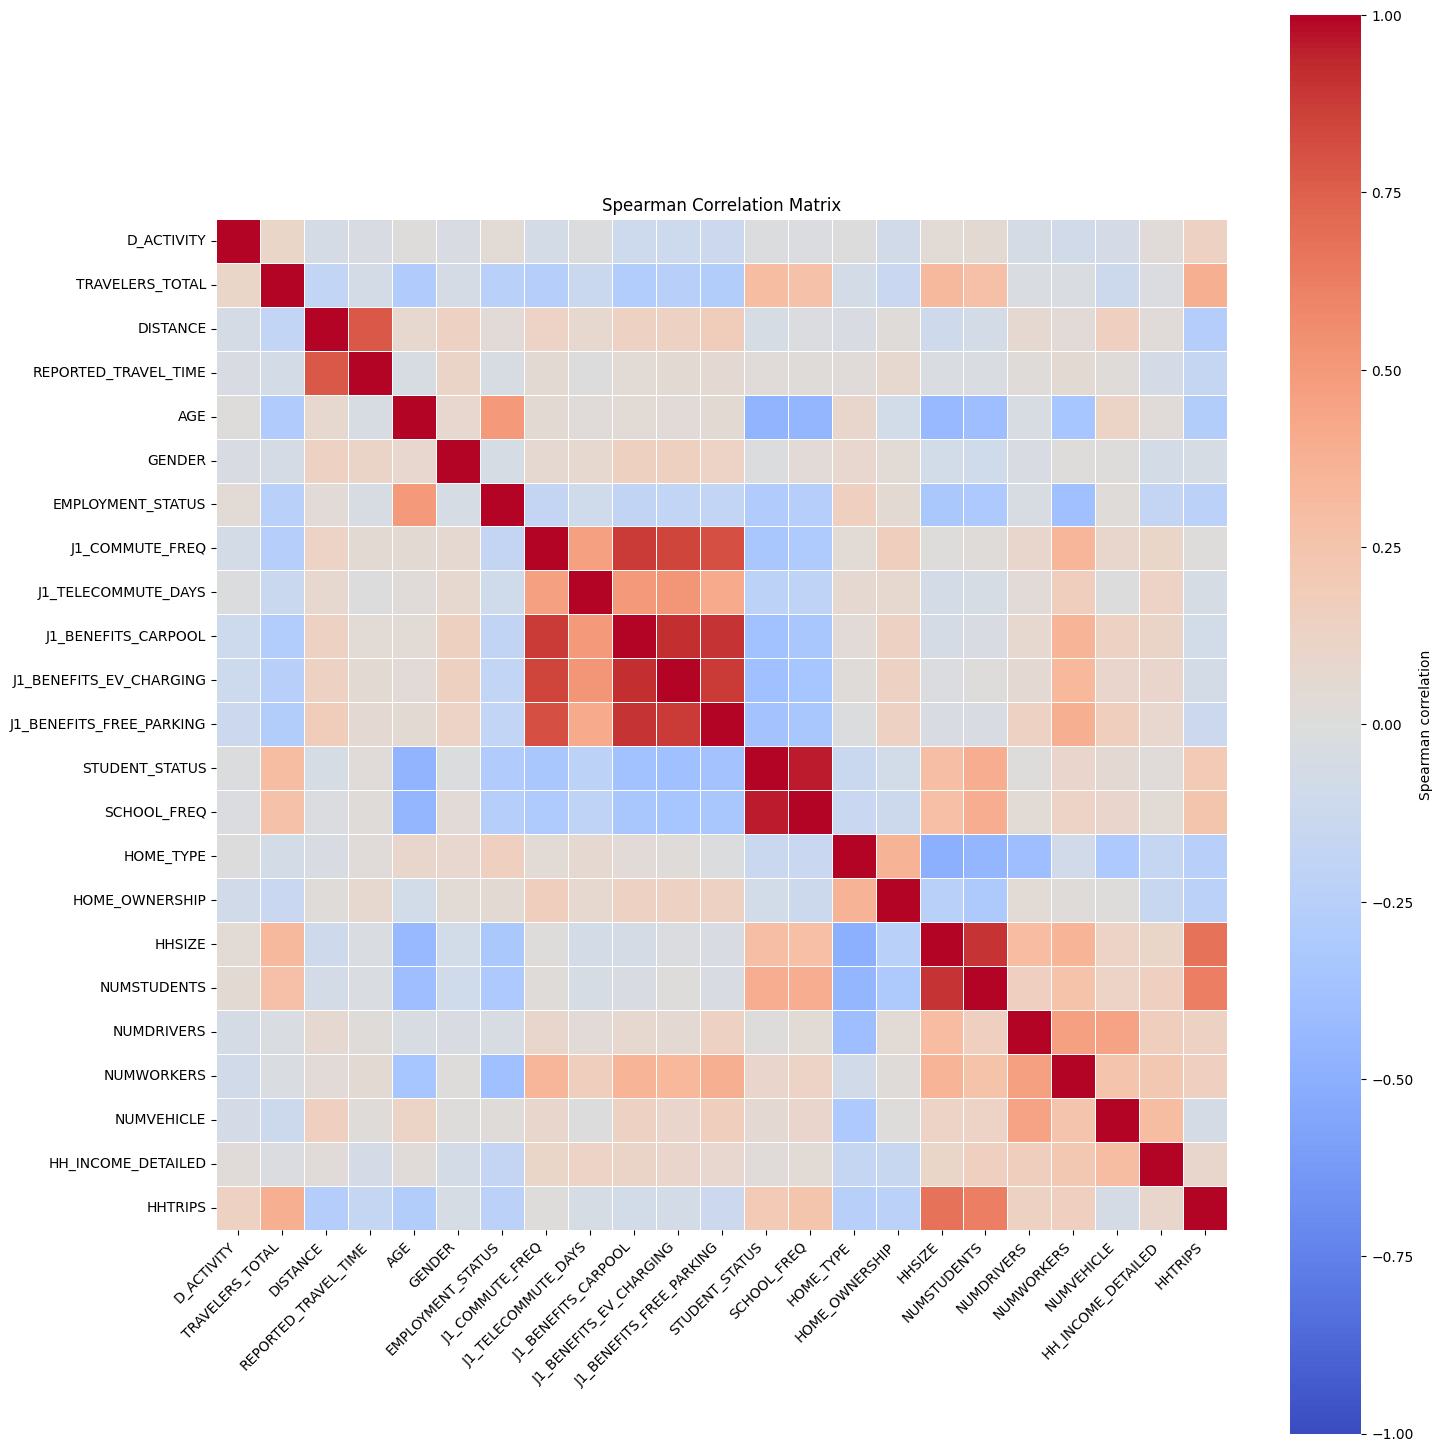

DISTANCE                    13.430028
TRAVELERS_TOTAL              9.060758
REPORTED_TRAVEL_TIME         4.971311
HOME_OWNERSHIP               3.291808
SCHOOL_FREQ                  2.092500
STUDENT_STATUS               1.731440
NUMVEHICLE                   1.644141
HOME_TYPE                    1.596846
J1_TELECOMMUTE_DAYS          1.329357
D_ACTIVITY                   1.109374
HHTRIPS                      0.764818
NUMSTUDENTS                  0.597883
HHSIZE                       0.244224
GENDER                      -0.033719
J1_COMMUTE_FREQ             -0.116748
NUMDRIVERS                  -0.213181
J1_BENEFITS_FREE_PARKING    -0.290250
J1_BENEFITS_EV_CHARGING     -0.292617
J1_BENEFITS_CARPOOL         -0.302201
AGE                         -0.383330
NUMWORKERS                  -0.722426
EMPLOYMENT_STATUS           -1.675347
HH_INCOME_DETAILED          -2.363328
dtype: float64

In [50]:


corr_matrix = df.corr(method = "spearman")
skewness = df.skew().sort_values(ascending = False)

plt.figure(figsize = (15, 15))
sns.heatmap(
    corr_matrix,
    cmap = "coolwarm",
    center = 0,
    vmin = -1,
    vmax = 1,
    square = True,
    linewidths = 0.5,
    cbar_kws = {"label": "Spearman correlation"},
)
plt.title("Spearman Correlation Matrix")
plt.xticks(rotation = 45, ha = "right")
plt.yticks(rotation = 0)
plt.tight_layout()
plt.show()

skewness